<a href="https://colab.research.google.com/github/mandavitripathi25/Customer-Segmentation/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import all the required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Load the data

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Dec_2025_PW_Batch/Machine Learning/Unsupervised_14June_4PM/Mall_Customers.csv')
data.shape

(200, 5)

In [ ]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Exploratory Data Analysis

Univariate Analysis

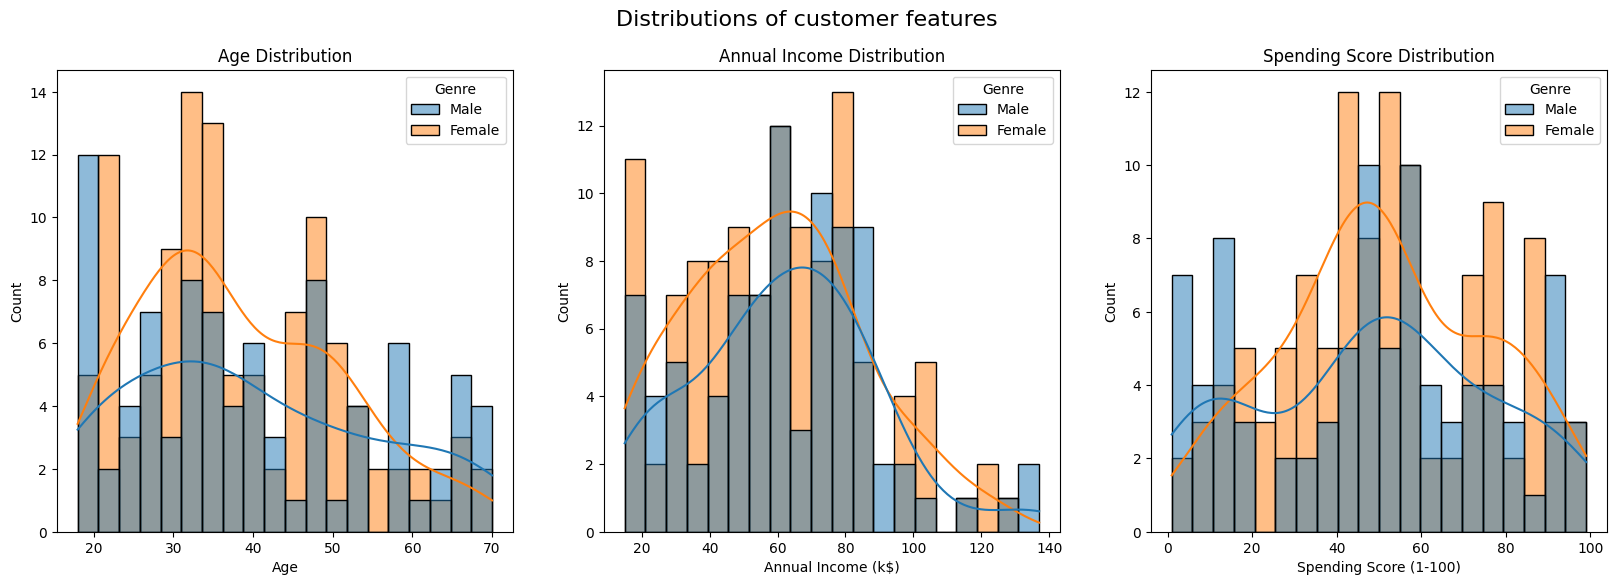

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Distributions of customer features', fontsize=16)

sns.histplot(ax=axes[0], data=data, x='Age', kde=True, bins=20, hue='Genre').set_title('Age Distribution')
sns.histplot(ax=axes[1], data=data, x='Annual Income (k$)', kde=True, bins=20, hue='Genre').set_title('Annual Income Distribution')
sns.histplot(ax=axes[2], data=data, x='Spending Score (1-100)', kde=True, bins=20, hue='Genre').set_title('Spending Score Distribution')

plt.show()

Bivariate Analysis

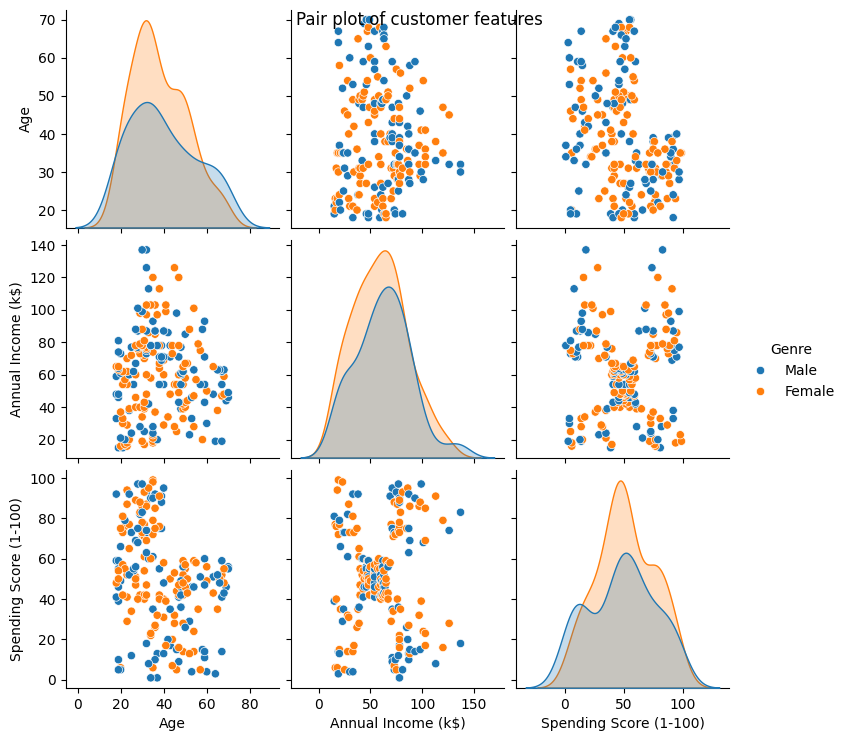

In [ ]:
sns.pairplot(data, vars=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], hue='Genre', diag_kind='kde')
plt.suptitle('Pair plot of customer features')
plt.show()

Observation:

- The Annual Income vs Spending Score plot is most revealing. It clearly shows distinct clusters possible.

- The Age vs Spending Score plot shows some patterns but they are less defined.

- Gender does not appear to be a strong separating factor in these plot, as the distributions for males and females are largely overlapping.

Optimal value of K via Elbow Method

In [ ]:
# select and scaled the input features
X1 = data[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)

# implement the elbow method
wcss = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X1_scaled)
  wcss.append(kmeans.inertia_)


print(wcss)


[399.99999999999994, 273.66888662642003, 157.70400815035939, 109.22822707921345, 65.56840815571681, 60.132874871934206, 49.668244837367965, 37.31912287833882, 32.495081199100916, 30.05932269404222]


Plot the Elbow Curve

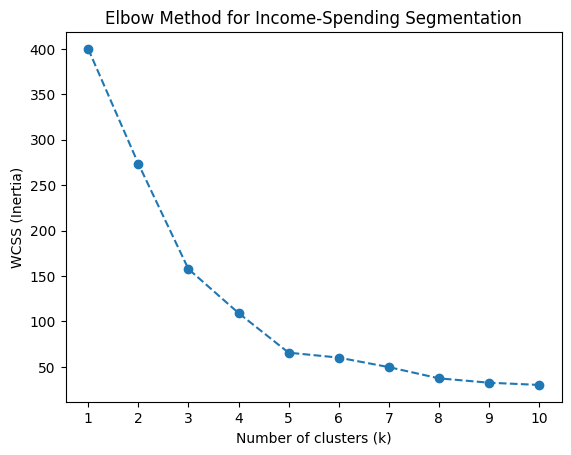

In [ ]:
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Income-Spending Segmentation')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.show()

Model Training

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
data['Income Cluster'] = kmeans.fit_predict(X1_scaled)
data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Income Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


Visualization

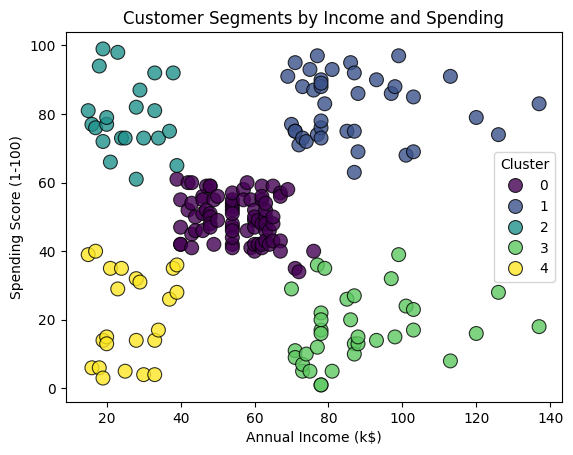

In [ ]:
sns.scatterplot(data=data, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Income Cluster', palette='viridis', s=100, alpha=0.8, edgecolor='black')
plt.title('Customer Segments by Income and Spending')
plt.legend(title='Cluster')
plt.show()

In [ ]:
data['Income Cluster'].value_counts()

,count
Income Cluster,
0,81
1,39
3,35
4,23
2,22


Task: Implement the KMeans clustering on Age and Spending Score

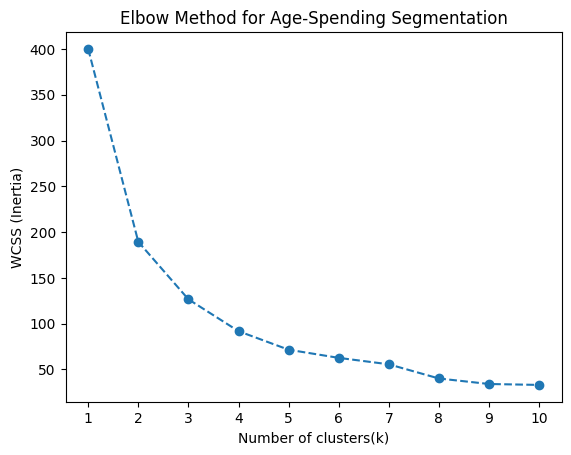

In [ ]:
X2 = data[['Age', 'Spending Score (1-100)']]

# scale the input feature
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)

# implement the elbow method
wcss = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X2_scaled)
  wcss.append(kmeans.inertia_)

# plot the elbow curve
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title("Elbow Method for Age-Spending Segmentation")
plt.xlabel('Number of clusters(k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
data['Age Cluster'] = kmeans.fit_predict(X2_scaled)

data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Age Cluster
0,1,Male,19,15,39,4,2
1,2,Male,21,15,81,2,1
2,3,Female,20,16,6,4,4
3,4,Female,23,16,77,2,1
4,5,Female,31,17,40,4,2


Visualization of the Age Clusters

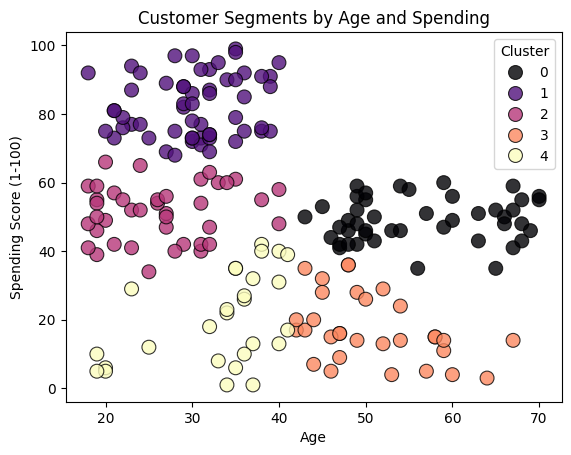

In [ ]:
sns.scatterplot(data=data, x='Age', y='Spending Score (1-100)',
                hue='Age Cluster', palette='magma', s=100, alpha=0.8, edgecolor='black')
plt.title('Customer Segments by Age and Spending')
plt.legend(title='Cluster')
plt.show()

Model Evaluation

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_val = silhouette_score(X1_scaled, data['Income Cluster'] )
print("Silhouette Score:", silhouette_val)

Silhouette Score: 0.5546571631111091


In [ ]:
from sklearn.metrics import silhouette_score
silhouette_val = silhouette_score(X2_scaled, data['Age Cluster'] )
print("Silhouette Score:", silhouette_val)

Silhouette Score: 0.410277640077836


How to improvise the results of the silhouette score?
*   Remove Outliers or handle them
*   K-Means assumes speherical clusters, similar cluster sizes with similar densities [different clustering algorithm]
*   n_init = 10 => run K-Means runs 10 times, in each iteration uses different initial centroids each time and compute the value of WCSS for each run.

run   wcss

1 => 175

2 => 162

3 => 121

4 => 148

5 => 118 [lowest WCSS or inertia]

6 => 132

7 => 145

8 => 124

9 => 119

10 => 126



n_init is the number of times K-Means is run with different initial centroid positions. Since K-Means is sensitive to initialization and can converge to a local optimum, multiple runs increase the likelihood of finding a better clustering solution. The algorithm selects the run with the lowest Within-Cluster Sum of Squares (WCSS), also called inertia.

Hierarchial Clustering

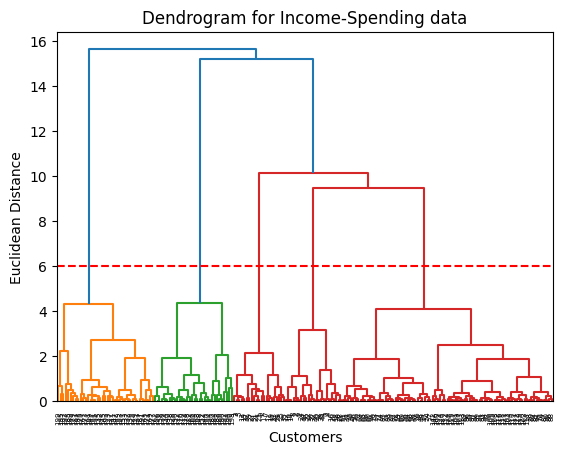

In [ ]:
import scipy.cluster.hierarchy as sch
dendogram = sch.dendrogram(sch.linkage(X1_scaled, method='ward'))
plt.title('Dendrogram for Income-Spending data')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.axhline(y=6, color='r', linestyle='--')
plt.show()

Insights: The dendrogram also confirms that 5 clusters is an optimal number for the income-spending data.

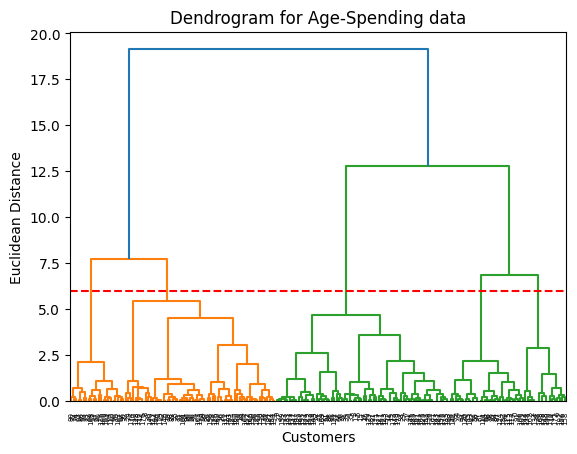

In [ ]:
import scipy.cluster.hierarchy as sch
dendogram = sch.dendrogram(sch.linkage(X2_scaled, method='ward'))
plt.title('Dendrogram for Age-Spending data')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.axhline(y=6, color='r', linestyle='--')
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
hierarchial_cluster = AgglomerativeClustering(n_clusters=5)
data['Income Hierarchial Cluster'] = hierarchial_cluster.fit_predict(X1_scaled)
data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Age Cluster,Income Hierarchial Cluster
0,1,Male,19,15,39,4,2,4
1,2,Male,21,15,81,2,1,3
2,3,Female,20,16,6,4,4,4
3,4,Female,23,16,77,2,1,3
4,5,Female,31,17,40,4,2,4
...,...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,1,1
196,197,Female,45,126,28,3,3,0
197,198,Male,32,126,74,1,1,1
198,199,Male,32,137,18,3,4,0


In [ ]:
silhouette_val = silhouette_score(X1_scaled, data['Income Hierarchial Cluster'] )
print("Silhouette Score:", silhouette_val)

Silhouette Score: 0.5538089226688662


DBSCAN Clustering Algorithm

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(min_samples=10)
data['Income DBSCAN Cluster'] = dbscan.fit_predict(X1_scaled)
data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Age Cluster,Income Hierarchial Cluster,Income DBSCAN Cluster
0,1,Male,19,15,39,4,2,4,-1
1,2,Male,21,15,81,2,1,3,0
2,3,Female,20,16,6,4,4,4,1
3,4,Female,23,16,77,2,1,3,0
4,5,Female,31,17,40,4,2,4,-1
...,...,...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,1,1,-1
196,197,Female,45,126,28,3,3,0,-1
197,198,Male,32,126,74,1,1,1,-1
198,199,Male,32,137,18,3,4,0,-1


In [ ]:
data['Income DBSCAN Cluster'].value_counts()

,count
Income DBSCAN Cluster,
0,109
2,32
3,26
-1,21
1,12


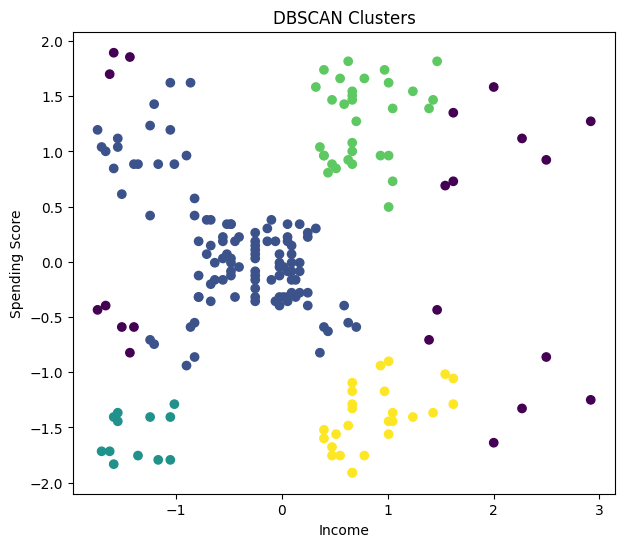

In [ ]:
plt.figure(figsize=(7,6))

plt.scatter(
    X1_scaled[:,0],
    X1_scaled[:,1],
    c = data['Income DBSCAN Cluster'],
    cmap='viridis'
)

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("DBSCAN Clusters")

plt.show()

In [ ]:
print(silhouette_score(X1_scaled, data['Income DBSCAN Cluster']))

0.4064046962444789


GridSearchCV => Implementation from scratch

In [ ]:
np.arange(0.2, 1.2, 0.05)

array([0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 ,
       0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05, 1.1 , 1.15])

In [ ]:
best_score = -1
best_eps = None
best_min_samples = None

for eps in np.arange(0.2, 1.2, 0.05):
  for min_samples in range(3, 11):
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X1_scaled)

    # ignore noise labels
    unique_clusters = set(labels)
    n_clusters = len(unique_clusters - {-1})

    if n_clusters < 2:
      continue

    score = silhouette_score(X1_scaled, labels)

    if score > best_score:
      best_score = score
      best_eps = eps
      best_min_samples = min_samples

print('Best eps: ', best_eps)
print('Best min_samples: ', best_min_samples)
print('Best silhouette score: ', best_score)

Best eps:  0.35
Best min_samples:  3
Best silhouette score:  0.4756158504262914


In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.35, min_samples=3)
data['Income DBSCAN Cluster_GridSearchCV'] = dbscan.fit_predict(X1_scaled)
data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Age Cluster,Income Hierarchial Cluster,Income DBSCAN Cluster,Income DBSCAN Cluster_GridSearchCV
0,1,Male,19,15,39,4,2,4,-1,0
1,2,Male,21,15,81,2,1,3,0,1
2,3,Female,20,16,6,4,4,4,1,2
3,4,Female,23,16,77,2,1,3,0,1
4,5,Female,31,17,40,4,2,4,-1,0
...,...,...,...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,1,1,-1,-1
196,197,Female,45,126,28,3,3,0,-1,-1
197,198,Male,32,126,74,1,1,1,-1,-1
198,199,Male,32,137,18,3,4,0,-1,-1


In [ ]:
print(silhouette_score(X1_scaled, data['Income DBSCAN Cluster_GridSearchCV']))

0.4756158504262914
